# Task 1: Email Spam Classification (using spam.csv from Kaggle)

#### Full Name: Yalda Ashrafi

#### Internship Domain: Machine Learning

#### Email Address: yaldaashrafi54@gmail.com

#### Phone Number: +60 11‑1330 4425

### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


#### Explanation
pandas: lets you load the dataset and organize it into tables, making it easy to explore and clean the data.

numpy: supports numerical operations, especially when handling arrays or calculations behind the scenes.

matplotlib & seaborn:  help you create clear visualizations like bar charts and heatmaps, so you can see patterns in the data.

train_test_split: divides your dataset into training and testing portions, ensuring you can train the model on one part and fairly evaluate it on another.

CountVectorizer & TfidfVectorizer: transform text messages into numbers that the machine learning model can understand, either by simple counts or by weighting words based on importance.

MultinomialNB : a Naive Bayes classifier that works especially well for text classification tasks such as spam detection.

accuracy_score, classification_report, confusion_matrix:  provide ways to measure how well your model performs, showing overall accuracy, detailed precision/recall/F1 scores, and where the model makes mistakes.

### Step 2: Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Explanation:
Load the dataset spam.csv.

Use encoding="latin-1" to avoid errors.

df.head() shows the first 5 rows.

### Step 3: Clean Dataset

In [35]:
print(df.columns)


Index(['label', 'message', 'clean_message'], dtype='object')


In [38]:
# Select only the relevant columns
df = df[['label', 'message']]

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Explanation:
The dataset contains three columns: label (ham/spam), message (original text), and clean_message (preprocessed text).
Only the relevant columns are selected to simplify the structure and avoid unnecessary data.
Renaming is not required since the columns are already clearly defined.
Finally, df.head() is used to display the first five rows and confirm the dataset structure before continuing.

### Step 4: Exploratory Data Analysis (EDA)

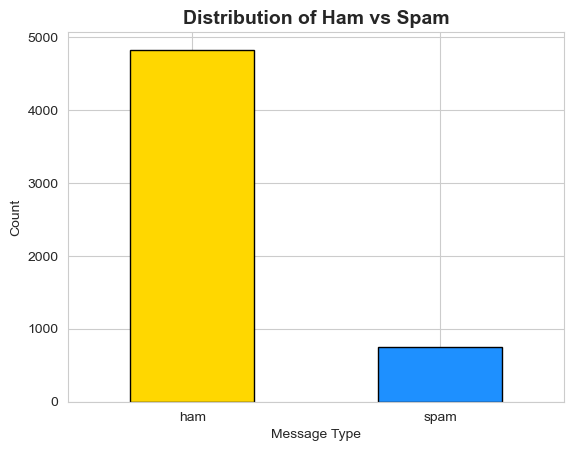

In [39]:
colors = ['#FFD700', '#1E90FF']  
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title("Distribution of Ham vs Spam", fontsize=14, fontweight='bold')
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### Explanation
This code visualizes the distribution of ham and spam messages in the dataset.

The value_counts() function counts how many samples belong to each label.

A bar chart is plotted using gold and dodger blue colors for better visual contrast.

Labels, title, and axis names make the chart easy to interpret.

The plot helps confirm whether the dataset is balanced or dominated by one class.



### Step 5: Preprocessing

In [40]:
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()  # convert all text to lowercase
    text = ''.join([ch for ch in text if ch not in string.punctuation])  
    words = text.split()  # split text into individual words
    words = [w for w in words if w not in stopwords.words('english')]  
    return ' '.join(words)  

df['clean_message'] = df['message'].apply(clean_text)

df.head()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yalda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


### Explanation
Convert text to lowercase: This keeps everything consistent, so words like “Free” and “free” are treated as the same.

Remove punctuation: Cleans out symbols such as !, ?, and . that don’t add meaning for spam detection.

Split and remove stopwords: Filters out common words like “the”, “and”, “is” that don’t help identify whether a message is spam or not.

Rejoin cleaned words: Combines the filtered words back into a single, clean sentence ready for feature extraction

### Step 6: Feature Extraction

In [22]:
# Features (X) are the cleaned text messages
X = df['clean_message']

# Labels (y) are ham/spam converted to 0/1
y = df['label'].map({'ham': 0, 'spam': 1})

# Convert text into numerical features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X)

# Split into training and testing sets (80/20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)


##### Explanation:

X = df['clean_message']: selects the cleaned text messages as the features for the model.

y = df['label'].map({'ham': 0, 'spam': 1}) → converts the labels into numbers (ham = 0, spam = 1) so the model can process them.

TfidfVectorizer(): transforms the text into numerical values based on word importance (TF‑IDF weighting).

fit_transform(X): learns the vocabulary from the dataset and creates the feature matrix.

train_test_split(...):  splits the dataset into training (80%) and testing (20%) sets, ensuring fair evaluation of the model.

In [41]:

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

# Show a few sample labels
print("First 10 labels in y_train:", y_train[:10].values)


Training set size: (4457, 9373)
Test set size: (1115, 9373)
First 10 labels in y_train: [0 1 0 0 1 0 1 0 0 0]


### Step 7: Train Model

In [17]:
model = MultinomialNB()
model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


### Explanation
model = MultinomialNB(): creates a Naive Bayes classifier, which is well‑suited for text classification problems like spam detection.

model.fit(X_train, y_train): trains the model using the training data (X_train features and y_train labels).

### Step 8: Evaluate Model

Accuracy: 0.9659192825112107

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



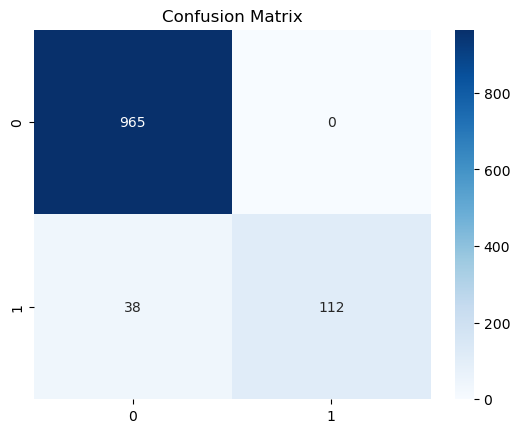

In [19]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


#### Explanation
Predict labels on test set: The trained model was used to classify unseen messages.

Print accuracy and classification report: Accuracy shows the overall correctness, while precision, recall, and F1‑score give deeper insight into performance for each class.

Interpret results:

The model is very strong at identifying ham (not spam) messages (recall = 1.00).

For spam, precision is perfect (1.00), meaning when it predicts spam, it’s correct, but recall is lower (0.75), meaning some spam messages were missed.

Plot confusion matrix heatmap: This visualization highlights where predictions were correct vs. incorrect, making it easier to spot weaknesses.